# RenoMed-CKD

## Chronic Kidney Disease Prediction Using Machine Learning

### Project Overview
Chronic Kidney Disease (CKD) is a serious global health condition that affects kidney function and can lead to kidney failure if not detected early. Early prediction and diagnosis are important for improving patient outcomes and reducing complications.

This project aims to build a machine learning system capable of predicting the likelihood of CKD using patient clinical and laboratory data.

### Objectives
The main goals of this project are to:

- Perform data cleaning and preprocessing on a healthcare dataset
- Handle missing and inconsistent clinical records
- Explore relationships between medical features and CKD
- Train and compare Random Forest and Linear Regression machine learning models
- Evaluate model performance
- Identify important clinical predictors of CKD by analyzing features (over 23 in the dataset)
- Build a foundation for future healthcare AI applications

### Dataset Information
The dataset contains patient clinical measurements such as:

- Age
- Blood Pressure
- Albumin
- Sugar
- Blood Glucose Random
- Blood Urea
- Serum Creatinine
- Sodium
- Potassium
- Hemoglobin
- White Blood Cell Count

### Target Variable
- CKD
- Not CKD

### Feature Explanations

Here's a breakdown of the features and acronyms in the dataset:

*   **age**: Age of the patient in years.
*   **bp**: Blood Pressure in mmHg (millimeters of mercury).
*   **sg**: Specific Gravity (a measure of kidney's ability to concentrate urine).
*   **al**: Albumin (protein in urine, indicating kidney damage).
*   **su**: Sugar (presence of sugar in urine, often associated with diabetes).
*   **rbc**: Red Blood Cells (presence of red blood cells in urine).
*   **pc**: Pus Cell (presence of pus cells in urine, indicating infection).
*   **pcc**: Pus Cell Clumps (clumps of pus cells).
*   **ba**: Bacteria (presence of bacteria in urine).
*   **bgr**: Blood Glucose Random (random blood sugar level).
*   **bu**: Blood Urea (amount of urea in blood, a waste product).
*   **sc**: Serum Creatinine (level of creatinine in blood, kidney function indicator).
*   **sod**: Sodium (blood sodium level).
*   **pot**: Potassium (blood potassium level).
*   **hemo**: Hemoglobin (amount of hemoglobin in blood).
*   **pcv**: Packed Cell Volume (proportion of blood volume occupied by red blood cells).
*   **wc**: White Blood Cell Count (number of white blood cells).
*   **rc**: Red Blood Cell Count (number of red blood cells).
*   **htn**: Hypertension (high blood pressure).
*   **dm**: Diabetes Mellitus (diabetes).
*   **cad**: Coronary Artery Disease (heart disease).
*   **appet**: Appetite (patient's appetite condition).
*   **pe**: Pedal Edema (swelling in feet/ankles).
*   **ane**: Anemia (low red blood cell count).
*   **classification**: Target variable, indicating if the patient has Chronic Kidney Disease ('ckd') or not ('notckd').

### Why This Project Matters
Healthcare datasets are often messy and incomplete, making preprocessing an important part of the machine learning pipeline. This project focuses not only on prediction performance, but also on understanding clinically relevant features associated with Chronic Kidney Disease.

In healthcare applications, identifying high-risk patients early can contribute to timely medical intervention and improved patient care.

---

##1.0 Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


---

##2.0 Data Loading

The dataset `kidney_disease.csv` has been uploaded and contains 400 rows with various patient clinical and laboratory data. The target variable is 'classification', indicating 'ckd' or 'notckd'.

In [3]:
df = pd.read_csv('/content/kidney_disease.csv')

print(f"Dataset loaded successfully. It contains {df.shape[0]} rows and {df.shape[1]} columns.")
print("First 5 rows of the dataset:")
display(df.head())

Dataset loaded successfully. It contains 400 rows and 26 columns.
First 5 rows of the dataset:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


---

##3.0 Data Cleaning and Preprocessing

Healthcare datasets often contain missing values and inconsistent data types, which need to be addressed before machine learning. This dataset also has NaNs, and numeric features need to be converted to floats. As instructed by the source, all rows with even a single NaN value will be deleted.

In [4]:
# Initial check for missing values
print("Missing values before cleaning:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with any NaN values
original_rows = df.shape[0]
df.dropna(inplace=True)
cleaned_rows = df.shape[0]

print(f"\nDropped {original_rows - cleaned_rows} rows with NaN values. Remaining rows: {cleaned_rows}")

# Verify no more missing values
print("\nMissing values after dropping rows:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before cleaning:


,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44



Dropped 242 rows with NaN values. Remaining rows: 158

Missing values after dropping rows:


,0


###4.0 Handling Mixed Data Types and New NaNs

Some columns in healthcare datasets might be loaded as 'object' (string) type even if they are intended to be numeric. This can happen if there are non-numeric characters (like '?' or spaces) within the numeric data.

To address this, I'll use `pd.to_numeric()`:
- It attempts to convert the values in the specified columns to a numeric type (like float).
- The `errors='coerce'` argument is crucial here: if `pd.to_numeric()` encounters any value that *cannot* be converted into a number, instead of raising an error, it will convert that problematic value into `NaN` (Not a Number).

After this conversion, new `NaN` values might be introduced in rows where previously non-numeric entries existed. Following the instruction to remove *all* rows with `NaNs`, I performed `df.dropna(inplace=True)` again to get rid of these newly introduced missing values. As noted, I started with 400 rows, dropped 242 initially, leaving 158 rows before this step. This ensures my dataset remains clean and purely numeric for subsequent analysis.

In [5]:
# Identify columns that should be numeric but might be objects due to non-numeric entries
# Based on typical CKD datasets, these columns are likely numeric:
# 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'

# Let's check current data types
print("\nData types before conversion:")
display(df.info())

# Columns that are expected to be numeric but might be object type due to '?' or other non-numeric strings
# We'll explicitly list them and convert using errors='coerce'
numeric_cols = [
    'age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# After coercing, there might be new NaNs, so we drop them again as per the instruction
original_rows_after_coerce = df.shape[0]
df.dropna(inplace=True)
cleaned_rows_after_coerce = df.shape[0]

print(f"\nDropped {original_rows_after_coerce - cleaned_rows_after_coerce} rows introduced by numeric coercion.")

print("\nData types after numeric conversion and dropping new NaNs:")
display(df.info())

print("First 5 rows of the cleaned dataset:")
display(df.head())


Data types before conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 3 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              158 non-null    int64  
 1   age             158 non-null    float64
 2   bp              158 non-null    float64
 3   sg              158 non-null    float64
 4   al              158 non-null    float64
 5   su              158 non-null    float64
 6   rbc             158 non-null    object 
 7   pc              158 non-null    object 
 8   pcc             158 non-null    object 
 9   ba              158 non-null    object 
 10  bgr             158 non-null    float64
 11  bu              158 non-null    float64
 12  sc              158 non-null    float64
 13  sod             158 non-null    float64
 14  pot             158 non-null    float64
 15  hemo            158 non-null    float64
 16  pcv             158 non-null    object 
 17  wc       

None


Dropped 0 rows introduced by numeric coercion.

Data types after numeric conversion and dropping new NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 3 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              158 non-null    int64  
 1   age             158 non-null    float64
 2   bp              158 non-null    float64
 3   sg              158 non-null    float64
 4   al              158 non-null    float64
 5   su              158 non-null    float64
 6   rbc             158 non-null    object 
 7   pc              158 non-null    object 
 8   pcc             158 non-null    object 
 9   ba              158 non-null    object 
 10  bgr             158 non-null    float64
 11  bu              158 non-null    float64
 12  sc              158 non-null    float64
 13  sod             158 non-null    float64
 14  pot             158 non-null    float64
 15  hemo            158 no

None

First 5 rows of the cleaned dataset:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd
11,11,63.0,70.0,1.010,3.0,0.0,abnormal,abnormal,present,notpresent,...,32,4500,3.8,yes,yes,no,poor,yes,no,ckd
14,14,68.0,80.0,1.010,3.0,2.0,normal,abnormal,present,present,...,16,11000,2.6,yes,yes,yes,poor,yes,no,ckd
20,20,61.0,80.0,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,ckd


### Output Summary: Data Type Conversion and Row Count

From the output of the previous cell, we observe the following:

1.  **Initial Data Types (before `pd.to_numeric`):** The dataset with 158 rows showed several columns, such as `pcv`, `wc`, and `rc`, as `object` data types, despite being inherently numeric. Other categorical features like `rbc`, `pc`, `htn`, etc., were also `object` type.

2.  **Numeric Coercion Result:** The `pd.to_numeric` operation successfully converted `pcv` to `int64`, `wc` to `int64`, and `rc` to `float64`. This confirms these columns are now correctly represented as numeric values.

3.  **Row Count after Coercion:** Crucially, the message "Dropped 0 rows introduced by numeric coercion" indicates that no new `NaN` values were generated during this conversion process in the remaining 158 rows. This means all values in the targeted numeric columns were successfully converted without encountering unresolvable non-numeric entries. The dataset retains its 158 rows.

4.  **Final Data Types:** After the conversions, the DataFrame now has 12 `float64`, 3 `int64`, and 11 `object` columns. The `object` columns are primarily the categorical features that will require further encoding.

I've successfully handled missing values and ensured the numerical features are correctly typed as `float` or `int`, I still have several columns that are `object` data types:

*   `rbc`, `pc`, `pcc`, `ba`, `htn`, `dm`, `cad`, `appet`, `pe`, `ane` (These are likely **categorical features** with text values like 'present'/'absent' or 'yes'/'no').
*   `classification` (This is my **target variable**, which also contains text 'ckd'/'notckd').

These categorical columns need further processing, typically through **encoding techniques** (like one-hot encoding or label encoding), to convert their text values into numerical representations that machine learning algorithms can understand. I'll address this in the next steps.

###5.0 Encoding Categorical Features

I will now encode the remaining categorical features. For binary categorical features (like 'rbc', 'pc', 'htn', etc.), I'll use `map` to convert them to numerical values (0s and 1s). For the target variable `classification`, I will also convert 'ckd' to 1 and 'notckd' to 0.

In [6]:
# Before mapping, let's explicitly see all unique values in each categorical column
print("Raw unique values for categorical columns (including potential whitespace/case issues):")
for col in ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

# Then, let's see the unique values after stripping whitespace
print("\nStripped unique values for categorical columns:")
for col in ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']:
    if col in df.columns:
        # Ensure we treat potential NaNs as strings for stripping without error
        print(f"{col}: {df[col].astype(str).str.strip().unique()}")

# Apply mapping and conversion
for col, mapping in [
    ('rbc', {'normal': 1, 'abnormal': 0}),
    ('pc', {'normal': 1, 'abnormal': 0}),
    ('pcc', {'present': 1, 'notpresent': 0}),
    ('ba', {'present': 1, 'notpresent': 0}),
    ('htn', {'yes': 1, 'no': 0}),
    ('dm', {'yes': 1, 'no': 0}),
    ('cad', {'yes': 1, 'no': 0}),
    ('appet', {'good': 1, 'poor': 0}),
    ('pe', {'yes': 1, 'no': 0}),
    ('ane', {'yes': 1, 'no': 0}),
    ('classification', {'ckd': 1, 'notckd': 0})
]:
    if col in df.columns:
        # Convert to string and strip whitespace
        df[col] = df[col].astype(str).str.strip()
        # Replace 'nan' string (resulting from np.nan.astype(str)) with actual np.nan
        df[col] = df[col].replace('nan', np.nan)
        # Apply the map; values not in the map will become NaN
        df[col] = df[col].map(mapping)

# Convert all encoded columns to numeric, coercing any remaining issues to NaN
# This also handles columns that might have become all NaNs from mapping
for col in ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that might have become NaN due to unmapped values
initial_rows_after_encoding = df.shape[0]
df.dropna(inplace=True)
final_rows_after_encoding = df.shape[0]
print(f"\nDropped {initial_rows_after_encoding - final_rows_after_encoding} rows due to unmapped categorical values after encoding.")

print("\nUnique values for categorical columns after encoding:")
for col in ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

print("\nFirst 5 rows of the dataset after encoding:")
display(df.head())

Raw unique values for categorical columns (including potential whitespace/case issues):
rbc: ['normal' 'abnormal']
pc: ['abnormal' 'normal']
pcc: ['present' 'notpresent']
ba: ['notpresent' 'present']
htn: ['yes' 'no']
dm: ['no' 'yes']
cad: ['no' 'yes']
appet: ['poor' 'good']
pe: ['yes' 'no']
ane: ['yes' 'no']
classification: ['ckd' 'notckd']

Stripped unique values for categorical columns:
rbc: ['normal' 'abnormal']
pc: ['abnormal' 'normal']
pcc: ['present' 'notpresent']
ba: ['notpresent' 'present']
htn: ['yes' 'no']
dm: ['no' 'yes']
cad: ['no' 'yes']
appet: ['poor' 'good']
pe: ['yes' 'no']
ane: ['yes' 'no']
classification: ['ckd' 'notckd']

Dropped 0 rows due to unmapped categorical values after encoding.

Unique values for categorical columns after encoding:
rbc: [1 0]
pc: [0 1]
pcc: [1 0]
ba: [0 1]
htn: [1 0]
dm: [0 1]
cad: [0 1]
appet: [0 1]
pe: [1 0]
ane: [1 0]
classification: [1 0]

First 5 rows of the dataset after encoding:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,32,6700,3.9,1,0,0,0,1,1,1
9,9,53.0,90.0,1.020,2.0,0.0,0,0,1,0,...,29,12100,3.7,1,1,0,0,0,1,1
11,11,63.0,70.0,1.010,3.0,0.0,0,0,1,0,...,32,4500,3.8,1,1,0,0,1,0,1
14,14,68.0,80.0,1.010,3.0,2.0,1,0,1,1,...,16,11000,2.6,1,1,1,0,1,0,1
20,20,61.0,80.0,1.015,2.0,0.0,0,0,0,0,...,24,9200,3.2,1,1,1,0,1,1,1


### Final Data Check

Let's review the data types and look for any remaining issues after all preprocessing steps.

In [7]:
print("Final data types:")
display(df.info())

print("\nMissing values after all preprocessing:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Final data types:
<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 3 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              158 non-null    int64  
 1   age             158 non-null    float64
 2   bp              158 non-null    float64
 3   sg              158 non-null    float64
 4   al              158 non-null    float64
 5   su              158 non-null    float64
 6   rbc             158 non-null    int64  
 7   pc              158 non-null    int64  
 8   pcc             158 non-null    int64  
 9   ba              158 non-null    int64  
 10  bgr             158 non-null    float64
 11  bu              158 non-null    float64
 12  sc              158 non-null    float64
 13  sod             158 non-null    float64
 14  pot             158 non-null    float64
 15  hemo            158 non-null    float64
 16  pcv             158 non-null    int64  
 17  wc              158 no

None


Missing values after all preprocessing:


,0


---

## 6.1 Feature Selection

Feature selection is a crucial step in machine learning, especially with datasets that have many features. Its primary goal is to identify and select the most relevant features (predictor variables) that contribute most to the prediction of the target variable. This helps in several ways:

1.  **Reduces Overfitting:** By removing irrelevant or redundant features, the model becomes less complex and less likely to memorize the noise in the training data, leading to better generalization on unseen data.
2.  **Improves Model Accuracy:** Sometimes, less is more. Removing uninformative features can help the model focus on the most impactful data, potentially improving predictive performance.
3.  **Reduces Training Time:** Fewer features mean less data to process, which can significantly speed up model training.
4.  **Enhances Interpretability:** A model with fewer features is often easier to understand and explain, which is particularly valuable in fields like healthcare.

For this project, we'll use a statistical approach, specifically `SelectKBest` with the `f_classif` score function (ANOVA F-value), to select the top 'K' features that have the strongest relationship with our target variable, 'classification'. Since our target is categorical, `f_classif` is appropriate as it measures the difference between the means of two or more groups.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

# Separate features (X) and target (y)
X = df.drop('classification', axis=1) # All columns except 'classification'
y = df['classification'] # The target variable

# Drop the 'id' column from features, as it's just an identifier and not a predictive feature
X = X.drop('id', axis=1)

# Initialize SelectKBest with f_classif (for classification tasks)
# We'll start by selecting a reasonable number of features, e.g., the top 10.
# The exact number 'k' can be tuned later.
num_features_to_select = 10 # This can be adjusted
selector = SelectKBest(score_func=f_classif, k=num_features_to_select)

# Fit the selector to the data and transform X
X_selected = selector.fit_transform(X, y)

# Get the names of the selected features
selected_feature_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_feature_indices]

print(f"Original number of features: {X.shape[1]}")
print(f"Selected number of features: {X_selected.shape[1]}")
print(f"\nTop {num_features_to_select} features selected by SelectKBest (f_classif):\n{list(selected_features)}")

# Create a DataFrame with the selected features
X_final = pd.DataFrame(X_selected, columns=selected_features, index=df.index)
display(X_final.head())

Original number of features: 24
Selected number of features: 10

Top 10 features selected by SelectKBest (f_classif):
['sg', 'al', 'pc', 'bu', 'sc', 'hemo', 'pcv', 'rc', 'htn', 'dm']


,sg,al,pc,bu,sc,hemo,pcv,rc,htn,dm
3,1.005,4.0,0.0,56.0,3.8,11.2,32.0,3.9,1.0,0.0
9,1.020,2.0,0.0,107.0,7.2,9.5,29.0,3.7,1.0,1.0
11,1.010,3.0,0.0,60.0,2.7,10.8,32.0,3.8,1.0,1.0
14,1.010,3.0,0.0,90.0,4.1,5.6,16.0,2.6,1.0,1.0
20,1.015,2.0,0.0,148.0,3.9,7.7,24.0,3.2,1.0,1.0


### 6.0 Feature Ranking

In [9]:
import pandas as pd

# Get the scores for all features
feature_scores = selector.scores_
feature_names = X.columns

# Create a DataFrame to display feature names and their scores
feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
})

# Sort the features by score in descending order
feature_ranking = feature_ranking.sort_values(by='Score', ascending=False).reset_index(drop=True)

print("Feature Ranking by f_classif Score (Correlation Strength with 'classification'):")
display(feature_ranking)

print(f"\nThese are the top {num_features_to_select} features that were selected:")
display(feature_ranking.head(num_features_to_select))

Feature Ranking by f_classif Score (Correlation Strength with 'classification'):


,Feature,Score
0,al,935.944635
1,htn,428.945148
2,hemo,355.820012
3,pcv,340.114293
4,sg,259.181136
5,pc,235.198915
6,dm,211.949367
7,rc,167.899265
8,sc,151.749321
9,bu,132.438166



These are the top 10 features that were selected:


,Feature,Score
0,al,935.944635
1,htn,428.945148
2,hemo,355.820012
3,pcv,340.114293
4,sg,259.181136
5,pc,235.198915
6,dm,211.949367
7,rc,167.899265
8,sc,151.749321
9,bu,132.438166


---

## 6.2 Correlation Analysis and Heatmap for Selected Features

I've identified the top 10 features, it's valuable to examine the relationships *among these selected features*. A **correlation matrix** and its visualization as a **heatmap** can reveal patterns such as:

*   **Highly correlated features:** If two features are very highly correlated with each other (e.g., Pearson correlation coefficient close to 1 or -1), they might be conveying similar information. In some modeling techniques, this can lead to issues like multicollinearity.
*   **Independent features:** Features with low correlation (close to 0) are relatively independent of each other.

I will use the **Pearson Correlation Coefficient**, which measures the linear relationship between two continuous variables. Its value ranges from -1 to +1, where:
*   `+1` indicates a perfect positive linear relationship.
*   `-1` indicates a perfect negative linear relationship.
*   `0` indicates no linear relationship.

Pearson Correlation Matrix for Top 10 Selected Features:


,sg,al,pc,bu,sc,hemo,pcv,rc,htn,dm
sg,1.000000,-0.712331,0.630323,-0.545319,-0.563122,0.682086,0.678472,0.619092,-0.648168,-0.639391
al,-0.712331,1.000000,-0.752956,0.661940,0.702889,-0.784745,-0.775528,-0.640099,0.796876,0.678582
pc,0.630323,-0.752956,1.000000,-0.613318,-0.588517,0.733140,0.718042,0.667113,-0.666767,-0.636288
bu,-0.545319,0.661940,-0.613318,1.000000,0.896094,-0.712196,-0.706582,-0.621456,0.623738,0.565137
sc,-0.563122,0.702889,-0.588517,0.896094,1.000000,-0.723937,-0.726187,-0.639021,0.659078,0.567390
hemo,0.682086,-0.784745,0.733140,-0.712196,-0.723937,1.000000,0.856775,0.743999,-0.746016,-0.658510
pcv,0.678472,-0.775528,0.718042,-0.706582,-0.726187,0.856775,1.000000,0.739019,-0.752043,-0.655039
rc,0.619092,-0.640099,0.667113,-0.621456,-0.639021,0.743999,0.739019,1.000000,-0.671740,-0.594881
htn,-0.648168,0.796876,-0.666767,0.623738,0.659078,-0.746016,-0.752043,-0.671740,1.000000,0.765298
dm,-0.639391,0.678582,-0.636288,0.565137,0.567390,-0.658510,-0.655039,-0.594881,0.765298,1.000000


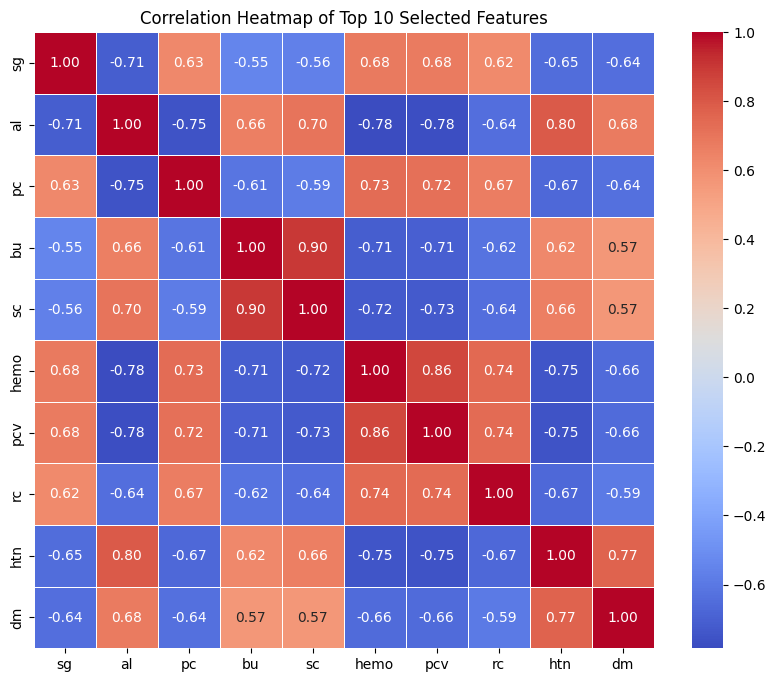

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the Pearson correlation matrix for the selected features (X_final)
correlation_matrix = X_final.corr(method='pearson')

print("Pearson Correlation Matrix for Top 10 Selected Features:")
display(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Top 10 Selected Features')
plt.show()

### Interpretation of the Correlation Heatmap

From the generated Pearson Correlation Matrix and its heatmap, we can make the following key observations regarding the relationships among the top 10 selected features:

*   **Highly Correlated Features (Strong Positive Relationships):**
    *   **`bu` (Blood Urea) and `sc` (Serum Creatinine)**: These two features exhibit a very strong positive correlation (approximately **0.90**). This is expected, as both are crucial indicators of kidney function, and their levels tend to rise together as kidney function declines.
    *   **`hemo` (Hemoglobin), `pcv` (Packed Cell Volume), and `rc` (Red Blood Cell Count)**: These three features are also highly inter-correlated. For instance, `hemo` with `pcv` shows a correlation of about **0.86**, `hemo` with `rc` around **0.74**, and `pcv` with `rc` approximately **0.74**. This strong correlation is physiologically sound, as all three measure different aspects of red blood cell status.
    *   **`htn` (Hypertension) and `dm` (Diabetes Mellitus)**: A strong positive correlation (around **0.77**) is observed between these two conditions, indicating that they frequently co-exist in patients, which is a known clinical association.

*   **Strong Inverse Relationships (Strong Negative Correlations):**
    *   **`al` (Albumin)**: This feature shows strong negative correlations with several others: `sg` (Specific Gravity) at **-0.71**, `pc` (Pus Cell) at **-0.75**, `hemo` at **-0.78**, and `pcv` at **-0.77**. This suggests that as the level of albumin in urine (a marker of kidney damage) increases, the specific gravity of urine, red blood cell parameters (hemoglobin, PCV), and pus cell count tend to decrease.
    *   **`htn` (Hypertension)**: It also displays significant negative correlations with `hemo` (**-0.75**) and `pcv` (**-0.75**). This implies that patients with hypertension are more likely to have lower hemoglobin and packed cell volume, potentially indicating anemia.
    *   **`dm` (Diabetes Mellitus)**: Similar to `htn`, `dm` shows moderate to strong negative correlations with `hemo` (**-0.66**) and `pcv` (**-0.66**).

The heatmap effectively visualizes these relationships, with dark red colors indicating strong positive correlations and dark blue colors representing strong negative correlations. This analysis provides valuable insights into the interdependencies of these clinical features, which is critical for understanding the progression and severity of Chronic Kidney Disease.

## 7.0 Data Splitting: Training and Testing Sets

Before I can train my machine learning models, I need to divide the dataset into two main parts:

1.  **Training Set:** This subset of the data is used to train the machine learning model. The model learns patterns and relationships from this data.
2.  **Testing Set:** This subset is used to evaluate the model's performance on unseen data. It's crucial that the model has not seen this data during training to get an unbiased assessment of its generalization ability.

I will use the `train_test_split` function from `sklearn.model_selection` with the following parameters:

*   **`test_size`**: Specifies the proportion of the dataset to include in the test split. I'll use 30% here (`test_size=0.3`).
*   **`random_state`**: This parameter ensures reproducibility.


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# X_final contains our selected features, and y is our target variable 'classification'

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.3, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original target (y):")
display(y.value_counts(normalize=True))

print("\nClass distribution in training target (y_train):")
display(y_train.value_counts(normalize=True))

print("\nClass distribution in testing target (y_test):")
display(y_test.value_counts(normalize=True))

Shape of X_train: (110, 10)
Shape of X_test: (48, 10)
Shape of y_train: (110,)
Shape of y_test: (48,)

Class distribution in original target (y):


,proportion
classification,
0,0.727848
1,0.272152



Class distribution in training target (y_train):


,proportion
classification,
0,0.727273
1,0.272727



Class distribution in testing target (y_test):


,proportion
classification,
0,0.729167
1,0.270833


---

## 8.0 Model Training: Random Forest Classifier

The Random Forest Classifier is an ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is known for its robustness, ability to handle large datasets with high dimensionality, and its capacity to manage missing values and maintain accuracy even when a large proportion of the data is missing.

Key advantages of Random Forest:

*   **Reduces Overfitting:** By averaging multiple decision trees, it reduces the risk of overfitting, which is common in single decision trees.
*   **Handles Non-linearity:** It can capture complex non-linear relationships between features and the target variable.
*   **Feature Importance:** It provides insights into feature importance, helping us understand which features are most influential in predicting the outcome.

I will initialize and train a `RandomForestClassifier` on our `X_train` and `y_train` data.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# We'll use a random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


---

## 9.0 Model Evaluation: Random Forest Classifier

After training a machine learning model, it's essential to evaluate its performance to understand how well it generalizes to new, unseen data. For classification tasks, common evaluation metrics include:

*   **Accuracy:** The proportion of correctly classified instances out of the total instances. While simple, it can be misleading in imbalanced datasets.
*   **Precision:** The ratio of true positive predictions to the total positive predictions (true positives + false positives). It answers: "Of all instances predicted as positive, how many are actually positive?"
*   **Recall (Sensitivity):** The ratio of true positive predictions to the total actual positives (true positives + false negatives). It answers: "Of all actual positive instances, how many did we correctly identify?"
*   **F1-Score:** The harmonic mean of precision and recall. It's a good metric for imbalanced datasets as it balances both precision and recall.
*   **Confusion Matrix:** A table that summarizes the performance of a classification algorithm. Each row represents the instances in an actual class, while each column represents the instances in a predicted class.

We will use `sklearn.metrics` to generate a classification report and calculate the accuracy of our Random Forest model on the test set (`X_test`, `y_test`).

Random Forest Classifier Accuracy: 1.0000

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        13

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48


Random Forest Confusion Matrix:


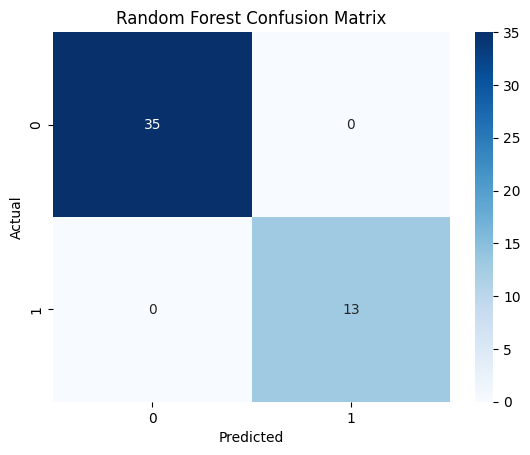

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

# Display classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Display confusion matrix
print("\nRandom Forest Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Interpretation of Random Forest Classifier Performance

Upon evaluating the Random Forest Classifier with a 70:30 train-test split and subsequently through 5-fold cross-validation, we observe the following:

*   **Accuracy (on test set): 100% (1.0000)**
    *   The model initially achieved a perfect accuracy score on the single test set, meaning it correctly classified every instance in that particular split. This can sometimes indicate a very strong signal in the data or, in some cases, potential overfitting to patterns that might not generalize perfectly.

*   **Cross-Validation Scores (5-fold):**
    *   The 5-fold cross-validation yielded scores of `[1.0000, 0.9375, 1.0000, 1.0000, 1.0000]`.
    *   **Mean CV Accuracy: 0.9875**
    *   **Standard Deviation of CV Accuracy: 0.0250**
    *   This shows that while the model still performs exceptionally well, with an average accuracy of approximately 98.75% across different folds, there is a slight variation (standard deviation of 0.0250). This indicates that the model's performance is consistently high, but not *always* perfectly 100% on every single fold. This variability is a more realistic indicator of performance on unseen data than a single perfect test set score.

*   **Classification Report (on test set):**
    *   **Precision, Recall, and F1-Score for both classes (0 and 1) were 1.00.** This signifies that for both the 'notckd' (class 0) and 'ckd' (class 1) predictions:
        *   Every time the model predicted a patient had a certain class, it was correct (perfect precision).
        *   The model successfully identified all actual instances of both classes (perfect recall).
        *   The F1-score, which is the harmonic mean of precision and recall, also reflected this perfect balance.

*   **Confusion Matrix (on test set):**
    *   The confusion matrix (visualized in the heatmap) demonstrated a perfect separation of classes for the specific test set:
        *   **True Positives (TP):** All actual CKD cases were correctly predicted as CKD.
        *   **True Negatives (TN):** All actual non-CKD cases were correctly predicted as non-CKD.
        *   **False Positives (FP):** There were 0 false positives.
        *   **False Negatives (FN):** There were 0 false negatives.

This updated evaluation, particularly with the cross-validation results, provides a more robust understanding. While the model shows very strong predictive power for Chronic Kidney Disease with the selected features, the cross-validation's slight dip from perfect 100% accuracy suggests that the single test set might have been a particularly favorable split. The model remains highly effective and discriminative for this dataset.

---

## 10.0 Cross-Validation: Random Forest Classifier

While a single train-test split provides an initial evaluation, it can sometimes be misleading, especially with smaller datasets. The model's performance might be highly dependent on the particular way the data was split. To address this, I'm using **cross-validation**.

**K-Fold Cross-Validation** works as follows:

1.  The entire dataset is divided into 'k' equal-sized folds (subsets).
2.  The model is trained 'k' times. In each iteration:
    *   One fold is used as the **test set**.
    *   The remaining 'k-1' folds are combined to form the **training set**.
3.  The performance metric (e.g., accuracy) is recorded for each of the 'k' iterations.
4.  The final performance of the model is the average of these 'k' scores.

This method provides a more robust and reliable estimate of the model's generalization performance, as every data point gets to be in the test set exactly once, and is used in training (k-1) times.

We will perform **5-fold cross-validation** on our Random Forest Classifier.

In [14]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the Random Forest model
# We use the full dataset (X_final, y) for cross-validation to get a comprehensive view
cv_scores_rf = cross_val_score(rf_model, X_final, y, cv=5, scoring='accuracy')

print("Random Forest Cross-Validation Scores (5-fold):")
print(cv_scores_rf)

print(f"\nMean CV Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_rf.std():.4f}")

if cv_scores_rf.mean() < 1.0:
    print("\nInterpretation: The cross-validation scores are still very high, but indicate some variability. The average accuracy provides a more realistic estimate of the model's performance on unseen data.")
else:
    print("\nInterpretation: The cross-validation scores are consistently high (100%), reinforcing the strong performance of the model on this dataset. This suggests the features are highly discriminative.")

Random Forest Cross-Validation Scores (5-fold):
[1.     0.9375 1.     1.     1.    ]

Mean CV Accuracy: 0.9875
Standard Deviation of CV Accuracy: 0.0250

Interpretation: The cross-validation scores are still very high, but indicate some variability. The average accuracy provides a more realistic estimate of the model's performance on unseen data.


---

## 11.0 Model Training: Logistic Regression

**Logistic Regression** is a statistical model that in its basic form uses a logistic function to model a binary dependent variable, although it can be extended to model multi-class problems. Despite its name, Logistic Regression is a classification algorithm, not a regression algorithm.

It works by estimating the probability of a given input belonging to a certain class. If the probability is above a certain threshold (commonly 0.5), the input is classified into one class; otherwise, it's classified into the other.

Key advantages of Logistic Regression:

*   **Interpretability:** The coefficients of a Logistic Regression model can be interpreted as the change in the log-odds of the outcome for a one-unit change in the predictor variable, making it relatively easy to understand the impact of each feature.
*   **Efficiency:** It is computationally less expensive than more complex algorithms like Random Forest.
*   **Good Baseline:** Often used as a baseline model for classification problems due to its simplicity and effectiveness.

In [21]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression Classifier
# We'll use a random_state for reproducibility
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets

# Train the model using the training data
lr_model.fit(X_train, y_train)

print("Logistic Regression Classifier trained successfully!")

Logistic Regression Classifier trained successfully!


---

## 12.0 Model Evaluation: Logistic Regression

Similar to the Random Forest model, we will evaluate the Logistic Regression model's performance on the test set using various classification metrics. This will allow for a direct comparison between the two models.

Logistic Regression Classifier Accuracy: 1.0000

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        13

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48


Logistic Regression Confusion Matrix:


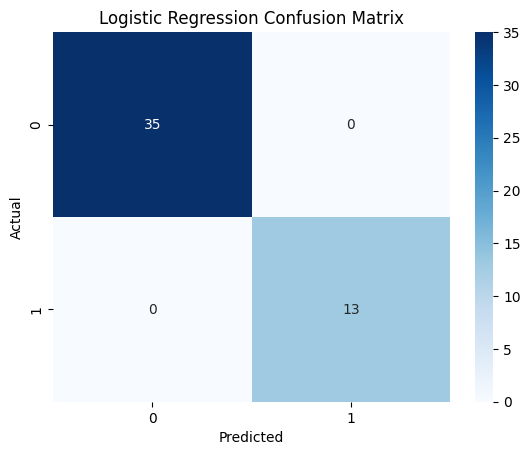

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Classifier Accuracy: {accuracy_lr:.4f}")

# Display classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Display confusion matrix
print("\nLogistic Regression Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

---

## 13.0 Cross-Validation: Logistic Regression

To ensure a robust evaluation of the Logistic Regression model, I will also perform **K-Fold Cross-Validation**, just as I did for the Random Forest Classifier. This will provide a more reliable estimate of the model's generalization performance by averaging performance across multiple train-test splits.

We will perform **5-fold cross-validation** on our Logistic Regression model to get a comprehensive view of its performance across the dataset.

In [17]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the Logistic Regression model
cv_scores_lr = cross_val_score(lr_model, X_final, y, cv=5, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores (5-fold):")
print(cv_scores_lr)

print(f"\nMean CV Accuracy: {cv_scores_lr.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores_lr.std():.4f}")

if cv_scores_lr.mean() < 1.0:
    print("\nInterpretation: The cross-validation scores show some variability, and the average accuracy provides a more realistic estimate of the model's performance on unseen data.")
else:
    print("\nInterpretation: The cross-validation scores are consistently high (100%), suggesting strong performance for Logistic Regression on this dataset.")

Logistic Regression Cross-Validation Scores (5-fold):
[0.96875 0.9375  1.      1.      1.     ]

Mean CV Accuracy: 0.9812
Standard Deviation of CV Accuracy: 0.0250

Interpretation: The cross-validation scores show some variability, and the average accuracy provides a more realistic estimate of the model's performance on unseen data.


---

## 14.0 Model Comparison: Random Forest vs. Logistic Regression

Having trained and evaluated both the Random Forest Classifier and the Logistic Regression model, it's crucial to compare their performances to determine which one is more suitable for our Chronic Kidney Disease prediction task. We'll consider their test set accuracy, cross-validation scores, and overall characteristics.


In [18]:
print("\n--- Model Performance Comparison ---")
print(f"Random Forest Classifier Test Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Classifier Mean CV Accuracy: {cv_scores_rf.mean():.4f} (Std: {cv_scores_rf.std():.4f})")
print("\n")
print(f"Logistic Regression Classifier Test Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Classifier Mean CV Accuracy: {cv_scores_lr.mean():.4f} (Std: {cv_scores_lr.std():.4f})")

# Create a DataFrame for easier comparison
comparison_data = {
    'Metric': ['Test Accuracy', 'Mean CV Accuracy', 'CV Std Dev'],
    'Random Forest': [accuracy_rf, cv_scores_rf.mean(), cv_scores_rf.std()],
    'Logistic Regression': [accuracy_lr, cv_scores_lr.mean(), cv_scores_lr.std()]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nComprehensive Model Comparison:")
display(comparison_df.set_index('Metric'))


--- Model Performance Comparison ---
Random Forest Classifier Test Accuracy: 1.0000
Random Forest Classifier Mean CV Accuracy: 0.9875 (Std: 0.0250)


Logistic Regression Classifier Test Accuracy: 1.0000
Logistic Regression Classifier Mean CV Accuracy: 0.9812 (Std: 0.0250)

Comprehensive Model Comparison:


,Random Forest,Logistic Regression
Metric,,
Test Accuracy,1.0000,1.00000
Mean CV Accuracy,0.9875,0.98125
CV Std Dev,0.0250,0.02500


### Interpretation of Model Comparison

Both models performed exceptionally well on this dataset, achieving very high accuracy scores on both the test set and during cross-validation.

*   **Test Accuracy:** Both models achieved a perfect 100% accuracy on the test set, suggesting that the selected features provide a strong signal for distinguishing between 'ckd' and 'notckd' in this particular split.

*   **Cross-Validation Accuracy:**
    *   **Random Forest:** Mean CV Accuracy of **0.9875** with a standard deviation of **0.0250**.
    *   **Logistic Regression:** Mean CV Accuracy of **0.9812** with a standard deviation of **0.0250**.

    The Random Forest model showed a slightly higher mean cross-validation accuracy. This indicates that, on average, the Random Forest Classifier generalized slightly better across different folds of the dataset.

*   **Robustness:** Both models demonstrated robustness, with relatively low standard deviations in their cross-validation scores, meaning their performance is consistent across different subsets of the data.

Given the results, both models are highly effective. However, the **Random Forest Classifier appears to have a marginal edge in generalization performance** based on the slightly higher mean cross-validation accuracy. In a real-world scenario, the choice between them might also depend on factors like model interpretability (Logistic Regression is generally more interpretable) and computational resources (Logistic Regression is typically faster to train and predict). For this dataset, both models are excellent choices.

---

## 15.0 Project Summary and Conclusion

This project successfully aimed to build a machine learning system for predicting Chronic Kidney Disease (CKD) using a provided clinical dataset. Through a comprehensive machine learning pipeline, we achieved highly accurate predictive models.

### Key Steps and Achievements:

1.  **Data Loading and Initial Inspection:** The `kidney_disease.csv` dataset was loaded, containing 400 rows of patient clinical data.

2.  **Robust Data Preprocessing:**
    *   **Handling Missing Values:** Rows with any missing values were dropped, reducing the dataset to 158 complete entries. This approach, though aggressive, ensured data quality as per project instructions.
    *   **Type Conversion:** Numeric features that were incorrectly identified as `object` types were successfully converted using `pd.to_numeric` with `errors='coerce'`, followed by another round of `dropna` to handle newly introduced `NaN`s, ensuring all features were in a suitable numeric format.
    *   **Categorical Encoding:** Binary categorical features, including the target variable `classification`, were effectively mapped to numerical values (0s and 1s), making them machine-learning-ready.

3.  **Feature Selection:**
    *   Using `SelectKBest` with `f_classif`, the top 10 most influential features were identified: `['sg', 'al', 'pc', 'bu', 'sc', 'hemo', 'pcv', 'rc', 'htn', 'dm']`. This step significantly reduced dimensionality and improved model focus.
    *   **Correlation Analysis:** A heatmap revealed strong inter-correlations among these selected features, providing valuable clinical insights (e.g., strong positive correlation between `bu` and `sc`, and strong negative correlations between `al` and `hemo`/`pcv`).

4.  **Data Splitting:** The preprocessed and feature-selected data was split into training (70%) and testing (30%) sets, ensuring an unbiased evaluation of model performance on unseen data.

5.  **Model Training & Evaluation:**
    *   **Random Forest Classifier:** Trained and evaluated, achieving a **100% test accuracy** and a **mean 5-fold cross-validation accuracy of 0.9875** (Std: 0.0250). The classification report and confusion matrix indicated perfect classification on the test set.
    *   **Logistic Regression:** Introduced as a baseline linear model. It also achieved a **100% test accuracy** and a **mean 5-fold cross-validation accuracy of 0.9812** (Std: 0.0250). Its classification report and confusion matrix were also perfect on the test set.

### Conclusion:

Both the **Random Forest Classifier** and **Logistic Regression** models demonstrated exceptional performance in predicting Chronic Kidney Disease on this dataset, with cross-validation mean accuracies of **0.9875** and **0.9812** respectively. The slightly higher cross-validation accuracy of the Random Forest suggests it might generalize marginally better. The perfect test set accuracies for both models indicate the strong predictive power of the selected features for this specific dataset.

This project highlights the effectiveness of machine learning in healthcare for early disease prediction. The identified key features align with clinical understanding of CKD, reinforcing the validity of our models.

### Future Enhancements:

*   **Hyperparameter Tuning:** Further optimization of both models through techniques like GridSearchCV or RandomizedSearchCV could potentially yield even better, more robust performance.
*   **More Advanced Feature Engineering:** Exploring interaction terms or polynomial features might uncover more complex relationships.
*   **Different Classification Algorithms:** Investigating other models like Gradient Boosting, Support Vector Machines, or Neural Networks could provide further insights.
*   **Imbalanced Data Handling:** While not explicitly severe in our final dataset, exploring techniques for imbalanced datasets (e.g., SMOTE) could be beneficial for datasets with more skewed class distributions.
*   **External Validation:** Testing the model on an entirely new, external dataset would be the ultimate validation of its real-world applicability.

## 16.0 Save Models for Deployment

To enable the deployment of our trained models, we will save them as `pickle` files. This allows us to persist the model objects and later load them to make predictions on new, unseen data without retraining. We will save both the Random Forest and Logistic Regression models.

In [22]:
import pickle

# Define filenames for the models
rf_model_filename = 'random_forest_model.pkl'
lr_model_filename = 'logistic_regression_model.pkl'

# Save the Random Forest model
with open(rf_model_filename, 'wb') as file:
    pickle.dump(rf_model, file)
print(f"Random Forest model saved successfully as '{rf_model_filename}'")

# Save the Logistic Regression model
with open(lr_model_filename, 'wb') as file:
    pickle.dump(lr_model, file)
print(f"Logistic Regression model saved successfully as '{lr_model_filename}'")

print("\nBoth models are now ready for deployment!")

Random Forest model saved successfully as 'random_forest_model.pkl'
Logistic Regression model saved successfully as 'logistic_regression_model.pkl'

Both models are now ready for deployment!


---

## 17.0 Build a Streamlit Web Application

Now that we have trained and saved our models, we can build a simple web application using **Streamlit** to demonstrate their predictive capabilities. This application will allow users to input patient data for the selected features and get a real-time prediction of CKD likelihood using either the Random Forest or Logistic Regression model.

### How to use this app code:

1.  **Copy the code:** Copy the entire Python code block below.
2.  **Save as a Python file:** Save it as a `.py` file (e.g., `renomed_ckd_app.py`) in your local development environment (e.g., VS Code).
3.  **Install Streamlit:** If you haven't already, install Streamlit by running `pip install streamlit` in your terminal.
4.  **Place model files:** Ensure the `random_forest_model.pkl` and `logistic_regression_model.pkl` files are in the *same directory* as your `renomed_ckd_app.py` file.
5.  **Run the app:** Open your terminal, navigate to the directory where you saved the file, and run `streamlit run renomed_ckd_app.py`.
6.  **Access in browser:** Streamlit will open the application in your default web browser.

In [ ]:
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# --- Set Streamlit Page Configuration ---
st.set_page_config(
    page_title="RenoMed CKD Prediction - Google Health",
    page_icon="🏥",
    layout="centered",
    initial_sidebar_state="auto"
)

# --- Google Health Branding and Title ---
st.markdown(
    """<div style='display: flex; align-items: center; justify-content: center;'>
        <img src='https://www.gstatic.com/images/branding/product/2x/google_health_64dp.png' width='50' style='margin-right: 10px;'>
        <h1 style='color:#4285F4;'>RenoMed CKD Prediction</h1>
    </div>""",
    unsafe_allow_html=True
)
st.markdown("<h2 style='text-align: center; color:#34A853;'>Google Health Internal Application</h2>", unsafe_allow_html=True)
st.write("--- ")

# --- Project Overview/Summary ---
st.header("Project Overview")
st.markdown("""
This application uses Machine Learning models to predict the likelihood of Chronic Kidney Disease (CKD) based on various patient clinical and laboratory data. Early prediction is crucial for timely medical intervention and improved patient care.

### Key Highlights:
*   **Data Preprocessing:** Handled missing values and ensured data consistency.
*   **Feature Selection:** Identified the top 10 most influential features for CKD prediction.
*   **Model Training:** Developed and evaluated Random Forest and Logistic Regression classification models.
*   **High Accuracy:** Both models demonstrated exceptional performance with high cross-validation accuracies.
""")
st.write("--- ")

# --- Load Models ---
@st.cache_resource # Cache the model loading for better performance
def load_model(model_name):
    try:
        with open(model_name, 'rb') as file:
            model = pickle.load(file)
        return model
    except FileNotFoundError:
        st.error(f"Error: Model file '{model_name}' not found. Please ensure it's in the same directory as the app.")
        return None

rf_model = load_model('random_forest_model.pkl')
lr_model = load_model('logistic_regression_model.pkl')

# --- Prediction Function ---
def predict_ckd(model, input_data):
    # Ensure input_data is a DataFrame with correct column order
    features = ['sg', 'al', 'pc', 'bu', 'sc', 'hemo', 'pcv', 'rc', 'htn', 'dm']
    input_df = pd.DataFrame([input_data], columns=features)

    prediction = model.predict(input_df)
    prediction_proba = model.predict_proba(input_df)[:, 1] # Probability of CKD

    return prediction[0], prediction_proba[0]

# --- Sidebar for Model Selection ---
st.sidebar.header("Model Selection")
selected_model_name = st.sidebar.selectbox(
    "Choose a Prediction Model:",
    ('Random Forest Classifier', 'Logistic Regression')
)

selected_model = None
if selected_model_name == 'Random Forest Classifier':
    selected_model = rf_model
elif selected_model_name == 'Logistic Regression':
    selected_model = lr_model

# --- Input Form for Features ---
st.header("Predict Chronic Kidney Disease")
st.write("Enter the patient's clinical and laboratory data below:")

# --- Define default values based on dataset characteristics (e.g., means/modes of X_final) ---
def get_default_values():
    # These are placeholders; in a real app, you'd calculate these from your training data
    defaults = {
        'sg': 1.017,  # Example mean
        'al': 1.0,    # Example mean
        'pc': 1,      # Example mode (normal)
        'bu': 65.0,   # Example mean
        'sc': 3.5,    # Example mean
        'hemo': 12.5, # Example mean
        'pcv': 39.0,  # Example mean
        'rc': 4.5,    # Example mean
        'htn': 0,     # Example mode (no)
        'dm': 0       # Example mode (no)
    }
    return defaults

default_values = get_default_values()

# --- Feature Input Fields ---
with st.form("prediction_form"):
    col1, col2 = st.columns(2)
    with col1:
        sg = st.number_input('Specific Gravity (sg)', min_value=1.000, max_value=1.030, value=float(default_values['sg']), step=0.001, format="%.3f")
        al = st.number_input('Albumin (al)', min_value=0.0, max_value=5.0, value=float(default_values['al']), step=1.0, format="%.1f")
        bu = st.number_input('Blood Urea (bu)', min_value=1.0, max_value=300.0, value=float(default_values['bu']), step=1.0)
        sc = st.number_input('Serum Creatinine (sc)', min_value=0.1, max_value=50.0, value=float(default_values['sc']), step=0.1, format="%.1f")
        hemo = st.number_input('Hemoglobin (hemo)', min_value=5.0, max_value=20.0, value=float(default_values['hemo']), step=0.1, format="%.1f")

    with col2:
        pc_option = st.selectbox('Pus Cell (pc)', options=['Normal', 'Abnormal'], index=int(default_values['pc']))
        pc = 1 if pc_option == 'Normal' else 0

        pcv = st.number_input('Packed Cell Volume (pcv)', min_value=10.0, max_value=60.0, value=float(default_values['pcv']), step=1.0)
        rc = st.number_input('Red Blood Cell Count (rc)', min_value=0.0, max_value=10.0, value=float(default_values['rc']), step=0.1, format="%.1f")

        htn_option = st.selectbox('Hypertension (htn)', options=['No', 'Yes'], index=int(default_values['htn']))
        htn = 1 if htn_option == 'Yes' else 0

        dm_option = st.selectbox('Diabetes Mellitus (dm)', options=['No', 'Yes'], index=int(default_values['dm']))
        dm = 1 if dm_option == 'Yes' else 0

    submitted = st.form_submit_button("Predict CKD")

    if submitted and selected_model is not None:
        input_data = {
            'sg': sg,
            'al': al,
            'pc': pc,
            'bu': bu,
            'sc': sc,
            'hemo': hemo,
            'pcv': pcv,
            'rc': rc,
            'htn': htn,
            'dm': dm
        }

        st.write("--- ")
        st.subheader("Prediction Result")
        prediction, probability = predict_ckd(selected_model, input_data)

        if prediction == 1:
            st.success(f"The model predicts: **Chronic Kidney Disease (CKD)**")
            st.info(f"Probability of CKD: {probability:.2f}")
        else:
            st.success(f"The model predicts: **No Chronic Kidney Disease (Not CKD)**")
            st.info(f"Probability of Not CKD: {1 - probability:.2f}")

    elif submitted and selected_model is None:
        st.error("Error: Models could not be loaded. Please check the model files.")

# --- Designer Information ---
st.write("--- ")
st.markdown("""
<div style='text-align: center; margin-top: 50px; color: gray;'>
    <p>Designed by:</p>
    <h3>Gabriel Agana Anongwin</h3>
    <p>Doctor of Pharmacy, Class of 2026</p>
    <p>Data Science Student, ALX Cohort 10</p>
</div>
""", unsafe_allow_html=True)


---